<a href="https://colab.research.google.com/github/Manemirandak/AquaLimpia/blob/main/ProyectoAquaLimpia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel ("/content/drive/MyDrive/CienciasDeDatos/datos/dataset_set_A_aguas_residuales.xlsx")

In [5]:
print(df.head())

  fecha_registro         planta  caudal_entrada_m3_d  DBO_entrada_mg_L  \
0     2025-08-17     Planta Sur                 6562               271   
1     2025-09-07     Planta Sur                 5336               322   
2     2025-07-26   Planta Norte                 5755               318   
3     2025-10-27  Planta Centro                 6840               216   
4     2025-09-06  Planta Centro                 6803               326   

   SST_entrada_mg_L  pH_entrada  energia_aeracion_kWh  lodos_generados_kg_d  \
0               324        7.12                1261.1                 440.3   
1               230        7.01                1629.3                 561.2   
2               282        6.79                1469.2                 441.6   
3               167        7.01                1764.8                 560.0   
4               200        7.55                1409.3                 654.0   

   DBO_salida_mg_L  cumplimiento_norma  
0             40.0                   0 

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fecha_registro        200 non-null    object 
 1   planta                200 non-null    object 
 2   caudal_entrada_m3_d   200 non-null    int64  
 3   DBO_entrada_mg_L      200 non-null    int64  
 4   SST_entrada_mg_L      200 non-null    int64  
 5   pH_entrada            200 non-null    float64
 6   energia_aeracion_kWh  200 non-null    float64
 7   lodos_generados_kg_d  200 non-null    float64
 8   DBO_salida_mg_L       200 non-null    float64
 9   cumplimiento_norma    200 non-null    int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 15.8+ KB
None


In [7]:
resumen = df.groupby("planta")[[
    "caudal_entrada_m3_d",
    "DBO_entrada_mg_L",
    "DBO_salida_mg_L",
    "energia_aeracion_kWh",
    "lodos_generados_kg_d"
]].mean()

# Mostrar resumen CALCULAR PROMEDIOS POR PLANTA
print(resumen)

               caudal_entrada_m3_d  DBO_entrada_mg_L  DBO_salida_mg_L  \
planta                                                                  
Planta Centro          5112.720000        285.186667        35.901333   
Planta Norte           5287.873239        275.845070        36.560563   
Planta Sur             4684.518519        278.796296        36.057407   

               energia_aeracion_kWh  lodos_generados_kg_d  
planta                                                     
Planta Centro           1260.854667            433.010667  
Planta Norte            1299.308451            450.471831  
Planta Sur              1193.775926            394.440741  


In [8]:
incumplimientos = df["cumplimiento_norma"].value_counts()

print(incumplimientos)

cumplimiento_norma
0    155
1     45
Name: count, dtype: int64


In [10]:
#EXPORTAR REPORTES EXCEL
# -----------------------------------------

# Reporte operaciones
reporte_operaciones = df[[
    "fecha_registro",
    "planta",
    "caudal_entrada_m3_d",
    "DBO_entrada_mg_L",
    "DBO_salida_mg_L",
    "energia_aeracion_kWh",
    "lodos_generados_kg_d"
]]

reporte_operaciones.to_excel(
    "/content/drive/MyDrive/CienciasDeDatos/reportes/reporte_operaciones.xlsx",
    index=False
)

# Reporte ambiental
reporte_ambiental = df[[
    "fecha_registro",
    "planta",
    "DBO_salida_mg_L",
    "cumplimiento_norma"
]]

reporte_ambiental.to_excel(
    "/content/drive/MyDrive/CienciasDeDatos/reportes/reporte_ambiental.xlsx",
    index=False
)

print("Reportes exportados correctamente")

Reportes exportados correctamente


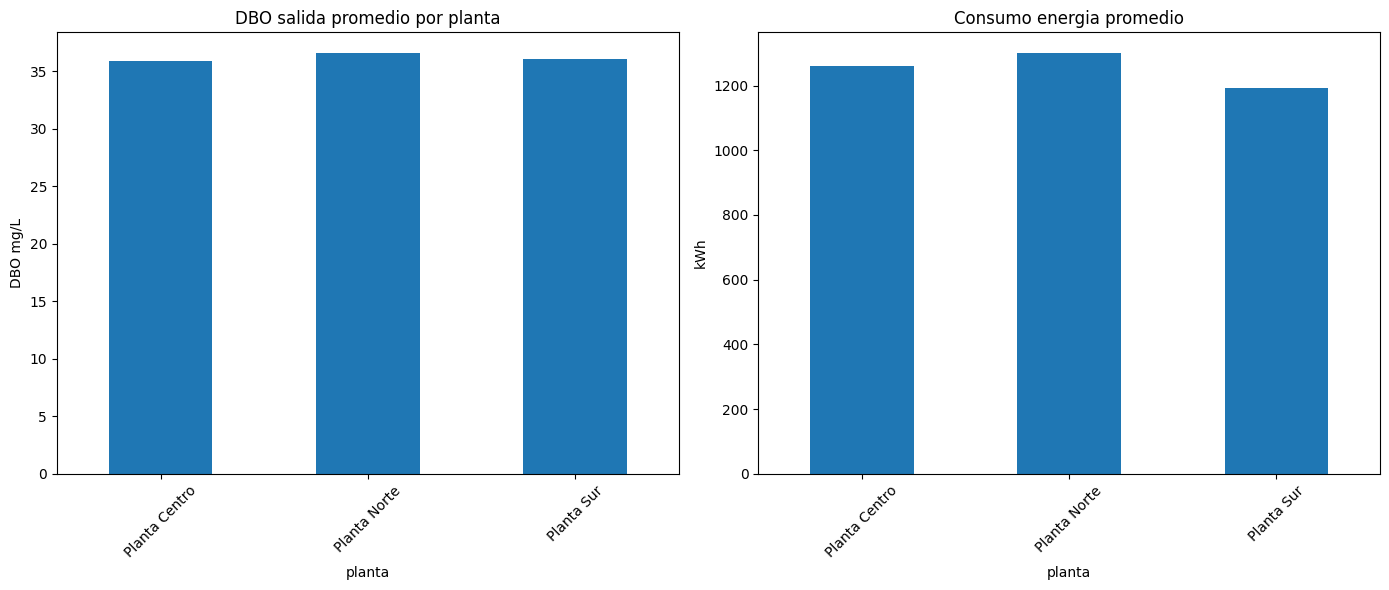

In [11]:
# DASHBOARD EXPLORATORIO

plt.figure(figsize=(14,6))


# GRAFICO DBO SALIDA PROMEDIO


plt.subplot(1,2,1)

resumen["DBO_salida_mg_L"].plot(
    kind="bar"
)

plt.title("DBO salida promedio por planta")
plt.ylabel("DBO mg/L")
plt.xticks(rotation=45)


# GRAFICO ENERGIA PROMEDIO


plt.subplot(1,2,2)

resumen["energia_aeracion_kWh"].plot(
    kind="bar"
)

plt.title("Consumo energia promedio")
plt.ylabel("kWh")
plt.xticks(rotation=45)


# AJUSTAR DASHBOARD


plt.tight_layout()


# GUARDAR IMAGEN


plt.savefig(
    "/content/drive/MyDrive/CienciasDeDatos/dashborads/dashboard_exploratorio.png"
)

# MOSTRAR DASHBOARD


plt.show()

In [14]:
markdown_texto = """
# Proyecto de Analisis de Datos
## AquaLimpia S.A.

---

# Descripcion del Proyecto

Este proyecto tiene como objetivo analizar el desempeño operacional y ambiental de las plantas de tratamiento de aguas residuales de AquaLimpia S.A., utilizando herramientas de ciencia de datos y visualizacion en Python.

El analisis busca identificar patrones asociados a incumplimientos normativos en los niveles de DBO, evaluar diferencias entre plantas y apoyar la toma de decisiones mediante dashboards y reportes automatizados.

---

# Objetivos del Proyecto

## Objetivo General

Analizar el comportamiento de las plantas de tratamiento de AquaLimpia S.A. para detectar patrones relevantes y apoyar la toma de decisiones operacionales y ambientales.

## Objetivos Especificos

- Analizar los niveles de DBO de entrada y salida.
- Comparar el desempeño de las distintas plantas.
- Evaluar el consumo energetico y generacion de lodos.
- Detectar posibles incumplimientos normativos.
- Construir dashboards exploratorios.
- Generar reportes para distintas areas de la empresa.

---

# Dataset Utilizado

Archivo:
`dataset_set_A_aguas_residuales.xlsx`

Variables principales:

- fecha_registro
- planta
- caudal_entrada_m3_d
- DBO_entrada_mg_L
- SST_entrada_mg_L
- pH_entrada
- energia_aeracion_kWh
- lodos_generados_kg_d
- DBO_salida_mg_L
- cumplimiento_norma

---

# Herramientas Utilizadas

- Python
- Pandas
- Matplotlib
- Google Colab
- GitHub

---

# Proceso Analitico

## 1. Carga de Datos

Se importo el dataset utilizando Pandas mediante la funcion:

```python
df = pd.read_excel("/content/dataset_set_A_aguas_residuales (1).xlsx")
```

## 2. Exploracion Inicial

Se revisaron:
- tipos de datos
- valores nulos
- estructura de columnas
- registros disponibles

## 3. Limpieza y Preparacion

Se verifico la calidad de los datos para evitar errores en el analisis.

## 4. Analisis Exploratorio

Se calcularon metricas promedio por planta utilizando `groupby()` para analizar:

- DBO salida
- consumo energetico
- generacion de lodos
- cumplimiento normativo

## 5. Visualizacion de Datos

Se construyo un dashboard exploratorio utilizando Matplotlib para representar graficamente:

- DBO promedio por planta
- consumo energetico promedio
- cumplimiento normativo

## 6. Generacion de Reportes

Se exportaron reportes diferenciados para:

- Area Operaciones
- Area Gestion Ambiental

---

# Resultados Principales

El analisis permitio identificar diferencias operacionales entre plantas de tratamiento, observando variaciones en los niveles de DBO de salida y en el consumo energetico. Ademas, el dashboard exploratorio facilito la deteccion visual de posibles focos de incumplimiento normativo y entrego informacion relevante para apoyar la toma de decisiones.

---

# Estructura del Proyecto

```text
AquaLimpia/
│
├── datos/
├── notebooks/
├── scripts/
├── reportes/
├── graficos/
└── README.md
```

---

# Repositorio GitHub

El proyecto se almacena en GitHub para facilitar:

- control de versiones
- trabajo colaborativo
- trazabilidad
- respaldo del proyecto

---

# Conclusiones

La utilizacion de herramientas de ciencia de datos permitio analizar el comportamiento de las plantas de tratamiento de AquaLimpia S.A. mediante un flujo reproducible y organizado. La documentacion tecnica favorece la comprension del proyecto, facilita la reutilizacion del analisis y fortalece la colaboracion entre las distintas areas involucradas.


"""


with open(
    "/content/drive/MyDrive/CienciasDeDatos/documentacion/README.md",
    "w"
) as archivo:

    archivo.write(markdown_texto)

print("Archivo README.md creado correctamente")

Archivo README.md creado correctamente


In [16]:

%%writefile /content/drive/MyDrive/CienciasDeDatos/scripts/funciones_analisis.py

import pandas as pd
import matplotlib.pyplot as plt


# FUNCION PARA CARGAR DATOS
def cargar_datos(ruta):

    df = pd.read_excel(ruta)

    return df


# FUNCION PARA CALCULAR PROMEDIOS
def calcular_promedios(df):

    resumen = df.groupby("planta")[[
        "DBO_entrada_mg_L",
        "DBO_salida_mg_L",
        "energia_aeracion_kWh",
        "lodos_generados_kg_d"
    ]].mean()

    return resumen


# FUNCION PARA GRAFICO
def grafico_dbo(resumen):

    resumen["DBO_salida_mg_L"].plot(
        kind="bar",
        figsize=(8,5)
    )

    plt.title("DBO salida promedio")
    plt.ylabel("DBO mg/L")
    plt.xticks(rotation=45)

    plt.show()

Writing /content/drive/MyDrive/CienciasDeDatos/scripts/funciones_analisis.py
